# Homework 1

In [1]:
#Packages 

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pickle
from matplotlib import cm

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics

Reading in the Ising Model data from Tutorial 1 (copied code from Tutorial 1)

In [3]:
#This is gratefully borrowed with permission from the notebooks maintained by P. Mehta.

######### LOAD DATA
######### The data consists of 16*10000 samples taken in T=np.arange(0.25,4.0001,0.25):
data_file_name = 'Ising2DFM_reSample_L40_T=All.pkl'
######### The labels are obtained from the following file:
label_file_name = 'Ising2DFM_reSample_L40_T=All_labels.pkl'


########## DATA
with open(data_file_name, 'rb') as pickle_file:
#r=read b=binary pickle must be read in binary mode and needs to be open
#with... as... will automatically close the file after opening it is safer
    data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data

#Decompress array and reshape for convenience
data = np.unpackbits(data).reshape(-1, 1600)
#data has byte (8bits) unpackbits unpack it into 8 bits return a bunch of 0 and 1s
#-1: figure out how many rows there are, each row has 1600=40*40 bits The length of the lattice is 40
data=data.astype('int')
#now convert the datatype to integer

#map 0 state to -1 (Ising variable can take values +/-1)
data[np.where(data==0)]=-1 
#np.where(data==0) find all indices where data is 0

######### READ LABELS (convention is 1 for ordered states and 0 for disordered states)
with open(label_file_name, 'rb') as pickle_file:
    labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)
print(data.shape) # the shape of the features
print(np.unique(labels)) # the unique labels

/var/folders/bg/5qsr84rd5gv3r39k5v2x0mm00000gn/T/ipykernel_94318/4101635478.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data


(160000, 1600)
[0 1]


/var/folders/bg/5qsr84rd5gv3r39k5v2x0mm00000gn/T/ipykernel_94318/4101635478.py:29: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)


Visualising some data examples (copied code form Tutorial 1)

<Figure size 1500x800 with 0 Axes>

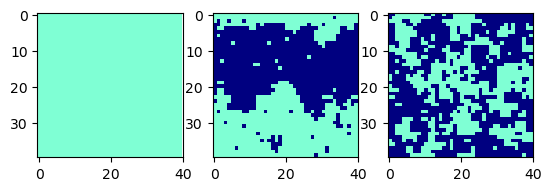

In [4]:
#H/T: https://stackoverflow.com/questions/16834861/create-own-colormap-using-matplotlib-and-plot-color-scale

cmap = matplotlib.colors.ListedColormap(["aquamarine","navy"], name='from_list', N=None)
#["aquamarine","navy"] list of color for each value
#name='from_list' optional name for the color list
#N=None  # optional number of entries (auto from list)
plt.figure(figsize=(15,8))
fig, axarr = plt.subplots(nrows=1, ncols=3)
axarr[0].imshow(data[0].reshape(40,40), cmap = cmap) #first object has label "1"
axarr[1].imshow(data[70000].reshape(40,40), cmap = cmap) #from documentation, this is critical-ish (between 60, and 90,000)
axarr[2].imshow(data[100000].reshape(40,40), cmap = cmap) #disordered
for i in range(3):
    axarr[i].set_xticks([0,20,40]);

Picking a random data selection (10%) to shuffle the data (copied code from Tutorial 1)

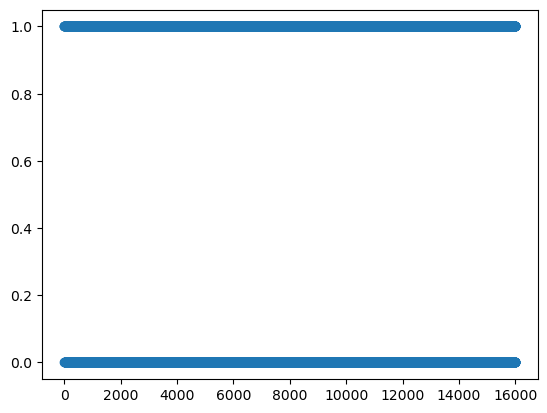

In [5]:
np.random.seed(228) #this random seed is carefully chosen so that one example is very special in the future

sel = np.random.choice(data.shape[0], data.shape[0]//10, replace = False)
#np.random.choice(
 #   a,         # range or array of values to choose from
 #   size,      # number of samples to pick
 #   replace=False  # without replacement → no repeats
#)
seldata = data[sel,:] # for all indices, select all data
sellabels = labels[sel]
plt.scatter(np.arange(seldata.shape[0]),sellabels); #The random selection has the advantage of reshuffling the data!

Logistic regression model (copied code from Tutorial 1)

In [6]:
#This uses a numerical method to find the minimum of the loss function
model = LogisticRegression(max_iter = 1000) 
#Takes up to 3 minutes
#We can use cross validation
#results is a dictionary you can access the train_score, test_score using the dictionary and compute mean and std etc
results = cross_validate(model, seldata, sellabels, 
                         cv = KFold(n_splits=5, shuffle=True, random_state=10), return_train_score = True)
print(results)

{'fit_time': array([1.0362072 , 1.20387101, 0.56026912, 0.75293303, 1.56105113]), 'score_time': array([0.0113728 , 0.00685   , 0.00571179, 0.0056181 , 0.00850391]), 'test_score': array([0.6796875, 0.685625 , 0.68625  , 0.6853125, 0.6825   ]), 'train_score': array([0.77984375, 0.7834375 , 0.77726562, 0.77664062, 0.7778125 ])}


Tuning hyperparameters

In [7]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}